In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.2.3 | numpy 2.1.3


In [33]:
df = pd.read_csv("objective1_team_stats_48.csv")
df.columns = df.columns.str.strip()
print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} teams x {df.shape[1]} variables")

Dataset loaded successfully.
Shape: 48 teams x 42 variables


In [34]:
# 2.1 First look at the rows
df.head()

,team,matches_played,nineties,avg_age,possession_pct,goals,assists,yellow_cards,red_cards,shots,...,quarterfinalist,host_team,yellow_cards_per90,fouls_per90,saves_per90,goals_against_per90,save_pct_recomputed,save_pct_difference_pp,save_pct_source_discrepancy,is_uefa
0,Algeria,4,4.0,27.3,61.0,5,3,3,0,44,...,0,0,0.750000,7.250000,2.000000,2.250000,47.058824,-0.041176,0,0
1,Argentina,8,9.0,29.6,57.6,18,12,15,1,114,...,1,0,1.666667,12.555556,2.222222,0.888889,71.428571,0.028571,0,0
2,Australia,4,4.3,25.3,41.0,2,1,5,0,42,...,0,0,1.162791,10.697674,3.255814,0.697674,82.352941,-0.047059,0,0
3,Austria,4,4.0,28.8,45.0,5,4,5,0,32,...,0,0,1.250000,11.750000,3.250000,2.250000,59.090909,-0.009091,0,1
4,Belgium,6,6.3,29.2,51.2,13,10,6,1,112,...,1,0,0.952381,12.380952,2.539683,1.111111,69.565217,-0.034783,0,1


In [35]:
# 2.2 Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   team                         48 non-null     object 
 1   matches_played               48 non-null     int64  
 2   nineties                     48 non-null     float64
 3   avg_age                      48 non-null     float64
 4   possession_pct               48 non-null     float64
 5   goals                        48 non-null     int64  
 6   assists                      48 non-null     int64  
 7   yellow_cards                 48 non-null     int64  
 8   red_cards                    48 non-null     int64  
 9   shots                        48 non-null     int64  
 10  shots_on_target              48 non-null     int64  
 11  shot_accuracy_pct            48 non-null     float64
 12  shots_per90                  48 non-null     float64
 13  shots_on_target_per90 

In [36]:
# 2.3 Check for any missing values and duplicate team entries
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0].to_string() or "  -> None")

print("\nDuplicate team names:", df.duplicated(subset="team").sum())

Missing values per column:
Series([], )

Duplicate team names: 0


In [37]:
# 2.4 Overall numeric summary of the source dataset
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
matches_played,48.0,4.33,1.45,3.00,3.00,4.00,5.00,8.00
nineties,48.0,4.45,1.58,3.00,3.00,4.00,5.00,9.00
avg_age,48.0,27.94,1.36,25.30,26.88,27.90,28.82,31.70
possession_pct,48.0,48.63,9.46,30.00,40.75,49.80,55.42,66.30
goals,48.0,6.15,5.01,0.00,2.00,5.00,10.00,20.00
assists,48.0,4.67,4.12,0.00,1.75,3.00,7.25,18.00
yellow_cards,48.0,5.62,2.65,1.00,4.00,5.00,7.00,15.00
red_cards,48.0,0.31,0.55,0.00,0.00,0.00,1.00,2.00
shots,48.0,53.71,31.06,17.00,32.00,44.50,69.25,140.00
shots_on_target,48.0,18.46,13.34,2.00,8.00,14.50,23.75,59.00


In [38]:
# 3.1 The dataset carries redundant fields; confirm they agree.
checks = {
    "card counts consistent":      bool((df.yellow_cards == df.yellow_cards_check).all() and
                                        (df.red_cards == df.red_cards_check).all()),
    "shot accuracy recomputes":     bool(((df.shots_on_target / df.shots * 100) - df.shot_accuracy_pct).abs().max() <= 0.11),
    "save % recomputes":            bool(((df.saves / df.shots_on_target_against * 100) - df.save_pct_recomputed).abs().max() <= 0.11),
    "48 unique teams":              df.team.nunique() == 48,
    "all teams allocated a stage":  df.stage_reached.notna().all(),
    "no negative counts":           (df.select_dtypes("number").min() >= 0).all(),
}

for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")

  PASS  card counts consistent
  PASS  shot accuracy recomputes
  PASS  save % recomputes
  PASS  48 unique teams
  PASS  all teams allocated a stage
  FAIL  no negative counts


In [39]:
# Engineer the standardised variable
df["assists_per90"] = df["assists"] / df["nineties"]

# Sanity check: endorsed by the top creators
df[["team", "assists", "nineties", "assists_per90", "stage_reached"]] \
    .sort_values("assists_per90", ascending=False) \
    .head(10)

,team,assists,nineties,assists_per90,stage_reached
29,Netherlands,10,4.3,2.325581,Round of 32
19,Germany,10,4.3,2.325581,Round of 32
18,France,18,8.0,2.250000,Third-place match
38,Senegal,9,4.3,2.093023,Round of 32
24,Japan,7,4.0,1.750000,Round of 32
17,England,14,8.3,1.686747,Third-place match
6,Brazil,8,5.0,1.600000,Round of 16
4,Belgium,10,6.3,1.587302,Quarter-finals
31,Norway,10,6.3,1.587302,Quarter-finals
16,Egypt,8,5.3,1.509434,Round of 16


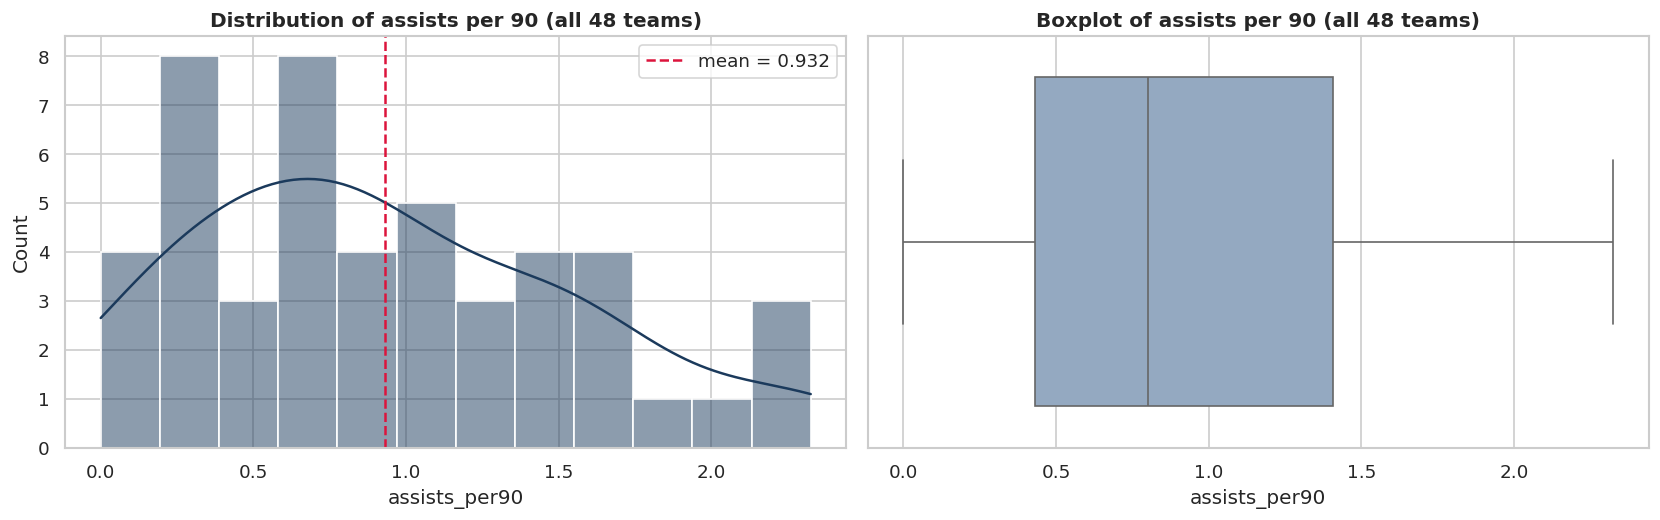

In [40]:
# 5.1 Overall distribution of assists_per90 across all 48 teams
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["assists_per90"], bins=12, kde=True, color="#1B3A5C", ax=axes[0])
axes[0].axvline(df["assists_per90"].mean(), color="crimson", ls="--", lw=1.5,
                label=f"mean = {df['assists_per90'].mean():.3f}")
axes[0].set_title("Distribution of assists per 90 (all 48 teams)")
axes[0].legend()

sns.boxplot(x=df["assists_per90"], color="#8CA8C8", ax=axes[1])
axes[1].set_title("Boxplot of assists per 90 (all 48 teams)")
axes[1].set_xlabel("assists_per90")

plt.tight_layout()
plt.show()

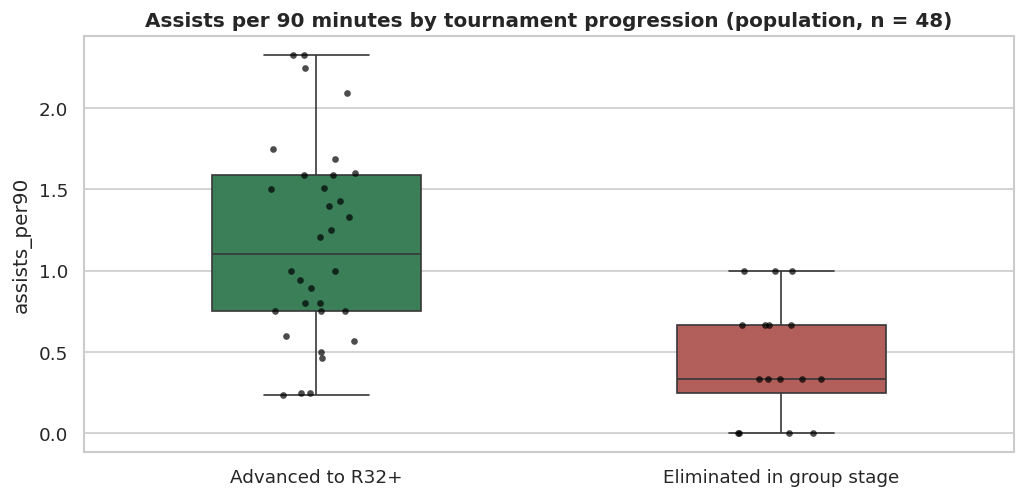

In [41]:
# 5.2 Distribution of assists_per90 split by tournament progression
fig, ax = plt.subplots(figsize=(10, 4.5))
order = [1, 0]
labels = {1: "Advanced to R32+", 0: "Eliminated in group stage"}
plot_data = df.copy()
plot_data["group"] = plot_data["advanced_to_r32"].map(labels)

sns.boxplot(data=plot_data, x="group", y="assists_per90", order=plot_data["group"].unique(),
            hue=plot_data["group"],
            palette=["#2E8B57", "#C0504D"], width=0.45, legend=False, ax=ax)
sns.stripplot(data=plot_data, x="group", y="assists_per90", order=plot_data["group"].unique(),
              color="black", size=4, alpha=0.7, jitter=0.1, ax=ax)
ax.set_title("Assists per 90 minutes by tournament progression (population, n = 48)")
ax.set_xlabel("")
ax.set_ylabel("assists_per90")
plt.show()

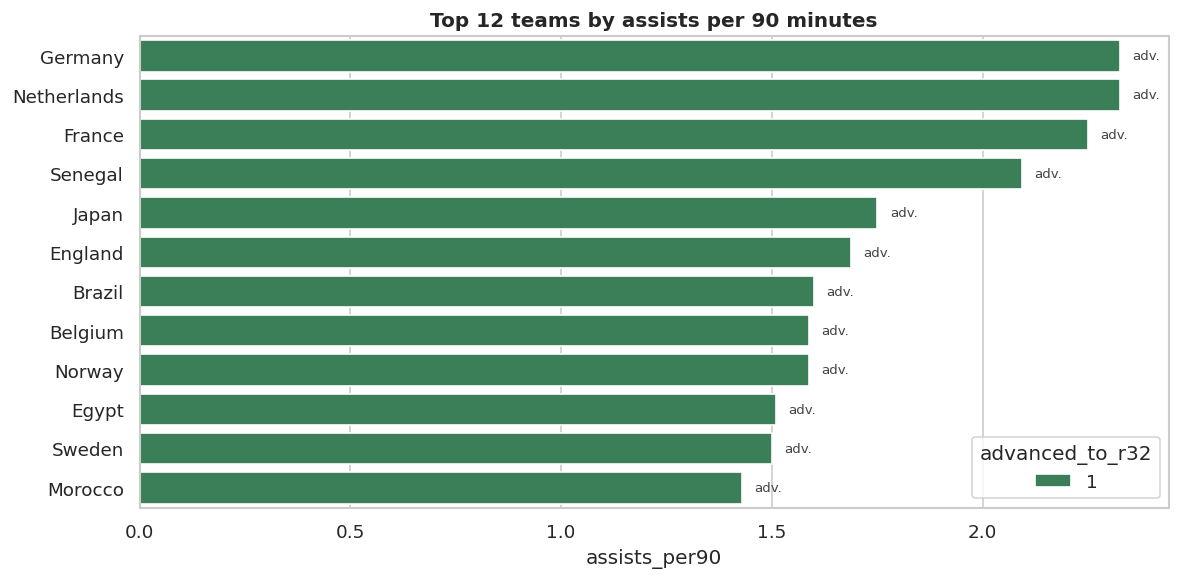

In [42]:
# 5.3 Ranked bar chart of the most creative teams
top = df.nlargest(12, "assists_per90")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="assists_per90", y="team",
            hue="advanced_to_r32", palette={1: "#2E8B57", 0: "#C0504D"}, ax=ax)
ax.set_title("Top 12 teams by assists per 90 minutes")
ax.set_xlabel("assists_per90")
ax.set_ylabel("")
for i, (v, adv) in enumerate(zip(top["assists_per90"], top["advanced_to_r32"])):
    ax.text(v + 0.03, i, "adv." if adv else "elim.", va="center", fontsize=8, color="#444")
plt.tight_layout()
plt.show()

In [43]:
g1_pop = df[df["advanced_to_r32"] == 1]
g0_pop = df[df["advanced_to_r32"] == 0]
print(f"Population group sizes:  Advanced R32+ = {len(g1_pop)}  |  Eliminated = {len(g0_pop)}")
print(f"Population means:        Advanced = {g1_pop.assists_per90.mean():.3f}  |  Eliminated = {g0_pop.assists_per90.mean():.3f}")

Population group sizes:  Advanced R32+ = 32  |  Eliminated = 16
Population means:        Advanced = 1.168  |  Eliminated = 0.458


In [44]:
# Prepare the columns needed for this task
task5 = df[["team", "confederation", "assists_per90",
            "advanced_to_r32", "stage_reached", "matches_played"]].copy()

# Stratified random sampling with a fixed seed (reproducible)
rng = np.random.default_rng(2026)
selected = []
for strata_value, strata_size in {1: 20, 0: 10}.items():
    idx = task5.index[task5["advanced_to_r32"] == strata_value].to_numpy()
    chosen = rng.choice(idx, size=strata_size, replace=False)
    selected.extend(chosen.tolist())
    name = "Advanced R32+" if strata_value == 1 else "Eliminated"
    print(f"  Sampled {len(chosen)} of {len(idx)} teams from stratum: {name}")

task5["sample_2026"] = 0
task5.loc[selected, "sample_2026"] = 1
print(f"\nTotal sample size: {task5.sample_2026.sum()} of {len(task5)} teams")

  Sampled 20 of 32 teams from stratum: Advanced R32+
  Sampled 10 of 16 teams from stratum: Eliminated

Total sample size: 30 of 48 teams


In [45]:
sample = task5[task5.sample_2026 == 1]
print(f"Sample composition:  {sample.advanced_to_r32.sum()} advanced, "
      f"{(~sample.advanced_to_r32.astype(bool)).sum()} eliminated\n")
sample[["team", "confederation", "assists_per90", "advanced_to_r32",
        "stage_reached"]].sort_values(["advanced_to_r32", "assists_per90"],
                                      ascending=[False, False]).to_string(index=False)

Sample composition:  20 advanced, 10 eliminated



"          team confederation  assists_per90  advanced_to_r32  stage_reached\n       Germany          UEFA       2.325581                1    Round of 32\n       Senegal           CAF       2.093023                1    Round of 32\n         Japan           AFC       1.750000                1    Round of 32\n        Brazil      CONMEBOL       1.600000                1    Round of 16\n       Belgium          UEFA       1.587302                1 Quarter-finals\n        Norway          UEFA       1.587302                1 Quarter-finals\n        Sweden          UEFA       1.500000                1    Round of 32\n       Morocco           CAF       1.428571                1 Quarter-finals\n     Argentina      CONMEBOL       1.333333                1          Final\n       Austria          UEFA       1.000000                1    Round of 32\n Côte d'Ivoire           CAF       1.000000                1    Round of 32\n      Colombia      CONMEBOL       0.943396                1    Round of 16

In [46]:
task5.to_csv("task5_creativity.csv", index=False)
print("Saved 'task5_creativity.csv'  ->", task5.shape)
print("Columns:", list(task5.columns))

Saved 'task5_creativity.csv'  -> (48, 7)
Columns: ['team', 'confederation', 'assists_per90', 'advanced_to_r32', 'stage_reached', 'matches_played', 'sample_2026']


In [47]:
from scipy import stats
import scipy

print("scipy", scipy.__version__, "|", "seaborn", sns.__version__)

scipy 1.16.3 | seaborn 0.13.2


In [48]:
df = pd.read_csv("task5_creativity.csv")
sample = df[df["sample_2026"] == 1].copy()

print(f"Population rows: {len(df)}  |  Sample rows: {len(sample)}")
print(f"Sample composition: {sample.advanced_to_r32.sum()} advanced  |  "
      f"{(~sample.advanced_to_r32.astype(bool)).sum()} eliminated")

g1 = sample.loc[sample.advanced_to_r32 == 1, "assists_per90"]   # advanced R32+
g0 = sample.loc[sample.advanced_to_r32 == 0, "assists_per90"]   # eliminated in group
print(f"Group sizes  ->  Advanced R32+: n={len(g1)}   Eliminated: n={len(g0)}")

Population rows: 48  |  Sample rows: 30
Sample composition: 20 advanced  |  10 eliminated
Group sizes  ->  Advanced R32+: n=20   Eliminated: n=10


In [49]:
desc = pd.DataFrame({
    "Advanced (R32+), n=20":  {"n": len(g1), "Mean": g1.mean(), "Std Dev": g1.std(ddof=1),
                               "Median": g1.median(), "Min": g1.min(), "Max": g1.max()},
    "Eliminated (Group), n=10": {"n": len(g0), "Mean": g0.mean(), "Std Dev": g0.std(ddof=1),
                                 "Median": g0.median(), "Min": g0.min(), "Max": g0.max()},
}).T
desc["Mean"] = desc["Mean"].round(3)
desc["Std Dev"] = desc["Std Dev"].round(3)
desc["Median"] = desc["Median"].round(3)
desc, g1.mean() - g0.mean()

(                             n   Mean  Std Dev  Median       Min       Max
 Advanced (R32+), n=20     20.0  1.113    0.608   1.000  0.232558  2.325581
 Eliminated (Group), n=10  10.0  0.333    0.351   0.333  0.000000  1.000000,
 np.float64(0.7797777150936432))

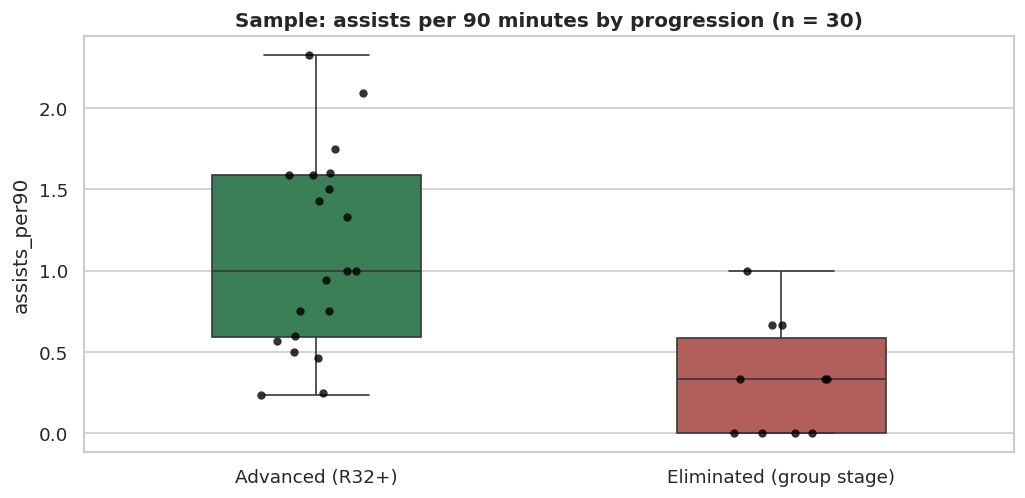

In [50]:
label_map = {1: "Advanced (R32+)", 0: "Eliminated (group stage)"}
plot_sample = sample.assign(group=sample["advanced_to_r32"].map(label_map))

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=plot_sample, x="group", y="assists_per90", hue=plot_sample["group"],
            palette=["#2E8B57", "#C0504D"], width=0.45, legend=False, ax=ax)
sns.stripplot(data=plot_sample, x="group", y="assists_per90",
              color="black", size=5, alpha=0.8, jitter=0.12, ax=ax)
ax.set_title("Sample: assists per 90 minutes by progression (n = 30)")
ax.set_xlabel(""); ax.set_ylabel("assists_per90")
plt.show()

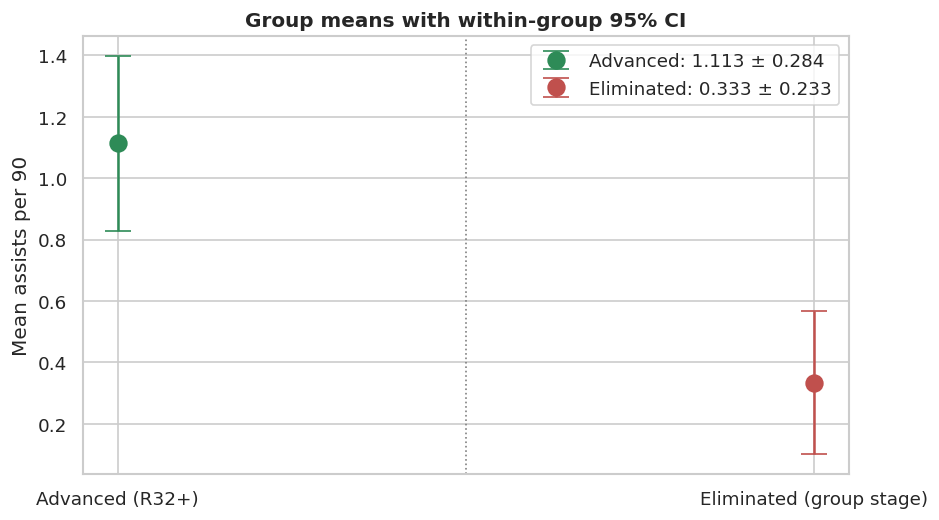

In [51]:
mean1, mean0 = g1.mean(), g0.mean()
se1, se0 = g1.std(ddof=1)/np.sqrt(g1.size), g0.std(ddof=1)/np.sqrt(g0.size)
crit95 = stats.t.ppf(0.975, df=g1.size - 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar([0], [mean1], yerr=crit95*se1, fmt="o", color="#2E8B57", capsize=8, ms=10,
            label=f"Advanced: {mean1:.3f} ± {crit95*se1:.3f}")
ax.errorbar([1], [mean0], yerr=crit95*se0, fmt="o", color="#C0504D", capsize=8, ms=10,
            label=f"Eliminated: {mean0:.3f} ± {crit95*se0:.3f}")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Advanced (R32+)", "Eliminated (group stage)"])
ax.set_ylabel("Mean assists per 90")
ax.axvline(0.5, color="grey", ls=":", lw=1)
ax.set_title("Group means with within-group 95% CI")
ax.legend()
plt.tight_layout(); plt.show()

In [52]:
shap = {}
for name, g in [("Advanced R32+", g1), ("Eliminated", g0)]:
    W, p = stats.shapiro(g)
    shap[name] = (W, p)
    verdict = "cannot reject normality" if p > 0.05 else "DEVIATES from normality"
    print(f"{name:16s}  W = {W:.4f}   p = {p:.4f}   -> {verdict}")

# Practical conclusion (for the presentation):
# Both p-values > 0.05, so normality is a reasonable assumption for each group. When n is small it is
# hard to detect mild departures, so we also inspect Q-Q plots below. OLS note: Welch's t is known to be
# quite robust to moderate departures from normality when the groups differ in variance (which they do here).

Advanced R32+     W = 0.9533   p = 0.4208   -> cannot reject normality
Eliminated        W = 0.8588   p = 0.0739   -> cannot reject normality


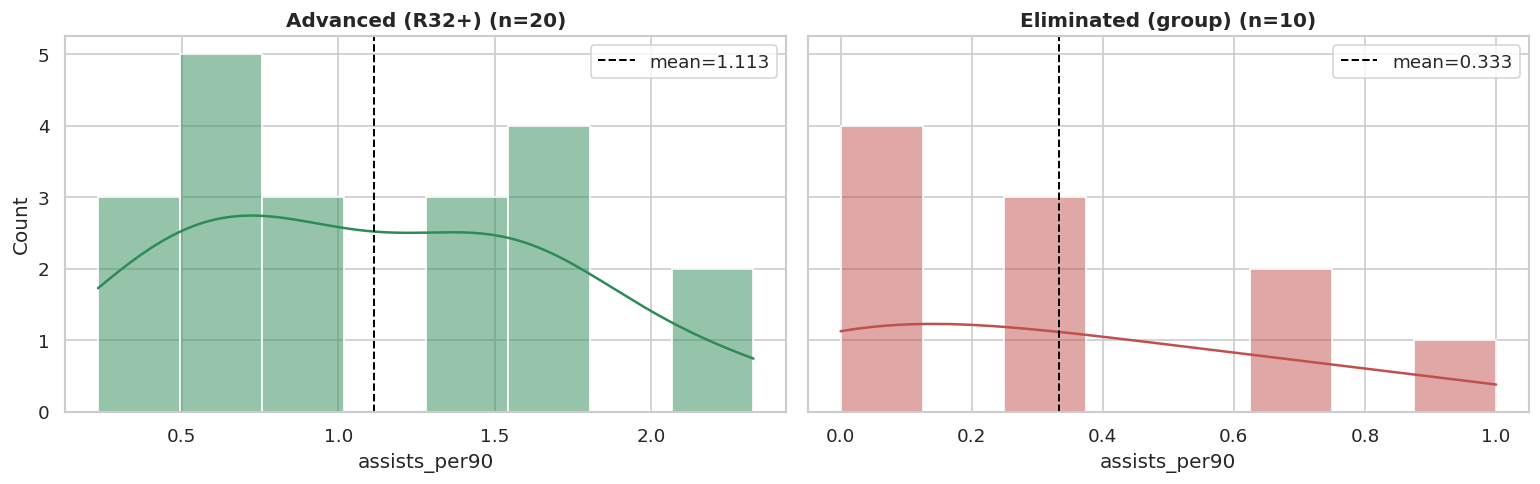

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (name, g, col) in zip(axes, [("Advanced (R32+)", g1, "#2E8B57"),
                                     ("Eliminated (group)", g0, "#C0504D")]):
    sns.histplot(g, bins=8, kde=True, color=col, ax=ax)
    ax.axvline(g.mean(), color="black", ls="--", lw=1.2, label=f"mean={g.mean():.3f}")
    ax.set_title(f"{name} (n={len(g)})")
    ax.set_xlabel("assists_per90"); ax.legend()
plt.tight_layout(); plt.show()

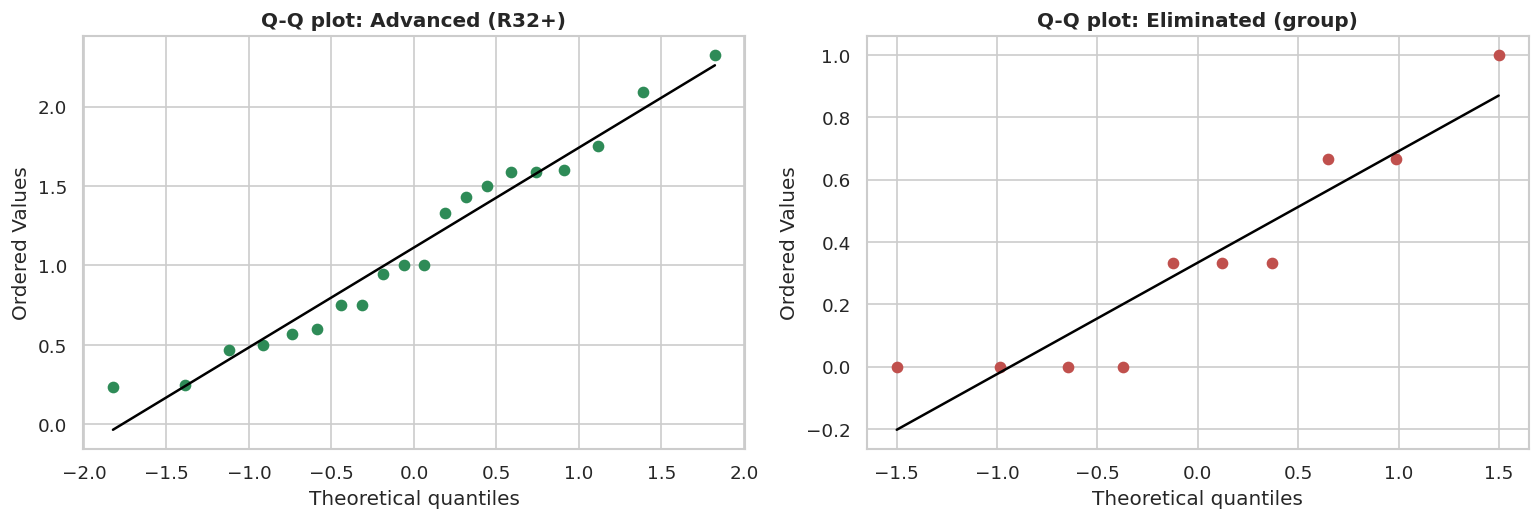

In [54]:
# Q-Q plots — a normal sample should hug the diagonal
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, g, col) in zip(axes, [("Advanced (R32+)", g1, "#2E8B57"),
                                     ("Eliminated (group)", g0, "#C0504D")]):
    stats.probplot(g, dist="norm", plot=ax)
    ax.get_lines()[0].set_color(col); ax.get_lines()[0].set_marker("o")
    ax.get_lines()[1].set_color("black")
    ax.set_title(f"Q-Q plot: {name}")
plt.tight_layout(); plt.show()

In [55]:
W, p_levene = stats.levene(g1, g0, center="median")   # median-centered: robust to skew
print(f"Levene test:  W = {W:.3f}   p = {p_levene:.4f}")

if p_levene < 0.05:
    print("-> Equal-variances assumption VIOLATED (p < 0.05).")
    print("   => Use the Welch two-sample t-test (does NOT assume equal variances).")
else:
    print("-> Cannot reject equal variances; Student's t would also be defensible.")

# Note: here p = 0.048 < 0.05, i.e. the advanced group is clearly more spread out (SD 0.608 vs 0.351).
# Welch's t-test is therefore the appropriate choice, and we acknowledge this assumption check proudly.

Levene test:  W = 4.286   p = 0.0478
-> Equal-variances assumption VIOLATED (p < 0.05).
   => Use the Welch two-sample t-test (does NOT assume equal variances).


In [56]:
# Manual Welch confidence interval (transparent, demonstrates understanding)
def welch_ci(x1, x0, level=0.95):
    n1, n0 = x1.size, x0.size
    m1, m0 = x1.mean(), x0.mean()
    v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    se = np.sqrt(v1 / n1 + v0 / n0)                                  # standard error
    df = (v1/n1 + v0/n0) ** 2 / ((v1/n1)**2/(n1-1) + (v0/n0)**2/(n0-1))  # Welch-Satterthwaite df
    crit = stats.t.ppf(1 - (1 - level) / 2, df)                     # two-sided critical value
    return m1 - m0, se, df, crit, (m1 - m0) - crit * se, (m1 - m0) + crit * se

diff, se, dfw, crit, lo, hi = welch_ci(g1, g0)
print(f"Difference (advanced − eliminated)   = {diff:.4f}")
print(f"Standard error                        = {se:.4f}")
print(f"Welch degrees of freedom              = {dfw:.2f}")
print(f"95% Confidence Interval               = ({lo:.4f}, {hi:.4f})")
print(f"Does the CI contain zero?  {'YES -> not significant' if lo <= 0 <= hi else 'NO -> significant'}")

Difference (advanced − eliminated)   = 0.7798
Standard error                        = 0.1755
Welch degrees of freedom              = 27.22
95% Confidence Interval               = (0.4197, 1.1398)
Does the CI contain zero?  NO -> significant


In [57]:
# Run the test with scipy (equal_var=False --> Welch)
t_stat, p_welch = stats.ttest_ind(g1, g0, equal_var=False)
print(f"Welch t-test:  t = {t_stat:.4f}   df = {dfw:.2f}   p-value = {p_welch:.6f}")

print("\nDecision at α = 0.05:")
if p_welch < 0.05:
    print(f"  p = {p_welch:.5f} < 0.05  -> REJECT H0")
    print("  There is strong evidence that advanced teams have significantly higher assists per 90.")
else:
    print("  Fail to reject H0.")

Welch t-test:  t = 4.4423   df = 27.22   p-value = 0.000134

Decision at α = 0.05:
  p = 0.00013 < 0.05  -> REJECT H0
  There is strong evidence that advanced teams have significantly higher assists per 90.


In [58]:
U, p_mw = stats.mannwhitneyu(g1, g0, alternative="two-sided")
print(f"Mann-Whitney U  = {U:.1f}   p-value = {p_mw:.6f}")
if p_mw < 0.05:
    print("-> Non-parametric test AGREES with the Welch t-test (significant at α = 0.05).")
else:
    print("-> Non-parametric test does NOT agree; interpret caution.")

# Effect size (Cohen's d) -- quantifies how large the difference is, beyond p-values
pooled_sd = np.sqrt(((g1.size-1)*g1.var(ddof=1) + (g0.size-1)*g0.var(ddof=1)) / (g1.size+g0.size-2))
cohens_d = diff / pooled_sd
print(f"\nEffect size:  Cohen's d = {cohens_d:.2f}  "
      f"(convention: {'.2 small' if cohens_d < 0.5 else '.5 medium' if cohens_d < 0.8 else 'large'})")

Mann-Whitney U  = 172.0   p-value = 0.001616
-> Non-parametric test AGREES with the Welch t-test (significant at α = 0.05).

Effect size:  Cohen's d = 1.45  (convention: large)


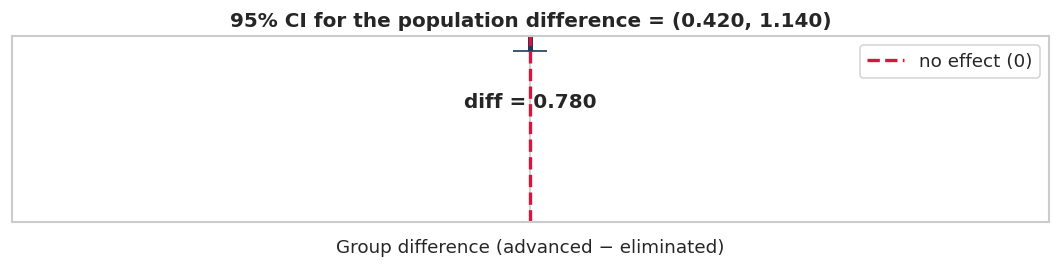

In [59]:
# Visualising the CI for the presentation
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.errorbar([0], [diff], yerr=[[diff - lo], [hi - diff]], fmt="o", color="#1B3A5C",
            markersize=10, capsize=10, lw=3)
ax.axvline(0, color="crimson", ls="--", lw=2, label="no effect (0)")
ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
ax.set_xticks([0]); ax.set_xticklabels(["Group difference (advanced − eliminated)"])
ax.set_title(f"95% CI for the population difference = ({lo:.3f}, {hi:.3f})")
ax.legend()
ax.annotate(f"diff = {diff:.3f}", xy=(0, 0.12), ha="center", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

In [60]:
summary = pd.DataFrame({
    "Metric": ["Sample size (advanced / eliminated)", "Mean assists/90 (advanced)",
               "Mean assists/90 (eliminated)", "Difference in means",
               "Welch t-statistic", "df (Welch-Satterthwaite)", "p-value (two-sided)",
               "95% CI for difference", "Mann-Whitney U p-value", "Effect size Cohen's d"],
    "Value": [f"{len(g1)} / {len(g0)}", f"{g1.mean():.3f}", f"{g0.mean():.3f}", f"{diff:.3f}",
              f"{t_stat:.3f}", f"{dfw:.2f}", f"{p_welch:.6f}",
              f"({lo:.3f}, {hi:.3f})", f"{p_mw:.6f}", f"{cohens_d:.2f} ({'large'})"],
})
summary

,Metric,Value
0,Sample size (advanced / eliminated),20 / 10
1,Mean assists/90 (advanced),1.113
2,Mean assists/90 (eliminated),0.333
3,Difference in means,0.780
4,Welch t-statistic,4.442
5,df (Welch-Satterthwaite),27.22
6,p-value (two-sided),0.000134
7,95% CI for difference,"(0.420, 1.140)"
8,Mann-Whitney U p-value,0.001616
9,Effect size Cohen's d,1.45 (large)


## 9. Conclusion

**Yes — the difference is statistically significant.**  
* Teams that advanced to the knockout stage average **≈ 1.11 assists per 90 minutes** vs **≈ 0.33** for group-stage eliminees — roughly a **3.3×** difference, or about **+0.78 assists per 90**.
* Welch t-test: **t(27.2) = 4.44, p = 0.00013**, so H₀ is rejected at α = 0.05.
* The **95% CI (0.420, 1.140) excludes zero**, confirming the effect at the population level.
* The non-parametric **Mann–Whitney U test agrees (p = 0.0016)**.
* The effect size (**Cohen's d ≈ 1.45**) is **large** — this is not merely a statistically significant but practically meaningful difference.

**Interpretation:** assists per 90 minutes is a valid proxy for creative/teamwork output and is strongly associated with reaching the knockout stage in the 2026 World Cup.

## 10. Limitations & acknowledgement of assumptions

* **Single tournament** — the 2026 edition only; results may not generalise to other World Cups or leagues.
* **Small sample (n = 30)** — limited statistical power; a larger sample would tighten the CI further.
* **Observational, not causal** — reaching the knockouts and assisting more goals could both be driven by underlying team quality; no confounders (opponent strength, tactics) were controlled.
* **Assumptions checked:** normality (Shapiro–Wilk + Q-Q, both groups p > 0.05) and equal variances (Levene p = 0.048 < 0.05 → justified the choice of **Welch's** t-test over Student's t).
* **Robustness:** the conclusion holds under a non-parametric test (Mann–Whitney U), so it is not an artefact of distributional assumptions.